# 01 — Dataset a příprava dat

Tenhle notebook ukazuje, **co jsou vstupní data a jak se z nich vyrobí to, co
potřebuje segmentační síť**. Odpovídá Fázi A a B z `devnotes/plan.md`.

Veškerá logika je ve skriptech v `scripts/` — notebook je jen volá a ukazuje
výsledky. Vysvětlení pojmů je v [`devnotes/teorie/`](../devnotes/teorie/).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))
from _common import *
import cv2, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
print("repo:", REPO_ROOT)

repo: C:\GitHub\USU-zapocet


## 1. Co je v datasetu

Dataset Atlas obsahuje **4963 párů**: rentgenový snímek krční páteře (PNG) a
k němu anotace ve formátu LabelMe (JSON).

In [2]:
stems = sorted(p.stem for p in JSON_DIR.glob("*.json"))
print(f"snímků: {len(list(IMAGES_DIR.glob('*.png')))}, anotací: {len(stems)}")

example = stems[0]
with open(JSON_DIR / f"{example}.json", encoding="utf-8") as f:
    ann = json.load(f)

print(f"\nklíče JSONu: {list(ann.keys())}")
print(f"rozlišení: {ann['imageWidth']} x {ann['imageHeight']}")
print(f"počet anotovaných útvarů: {len(ann['shapes'])}")

snímků: 4963, anotací: 4963

klíče JSONu: ['version', 'flags', 'shapes', 'imagePath', 'imageData', 'imageHeight', 'imageWidth']
rozlišení: 802 x 1014
počet anotovaných útvarů: 23


## 2. Klíčové zjištění: anotace NEJSOU polygony

Původní návrh práce předpokládal, že anotace obsahují obtahové polygony —
tedy desítky bodů kopírujících hranu obratle. Ve skutečnosti jde o **bodové
landmarky**: každý útvar má v poli `points` jediný bod a rozhoduje jeho `label`.

Schéma je:
- obratle **C3–C7**: 4 rohové body (`top left`, `top right`, `bottom right`, `bottom left`)
- obratel **C2**: jen 3 body (`bottom left`, `bottom right`, `centroid`) — má
  anatomicky odlišný tvar kvůli zubu čepovce

Pozor na past: `shape_type` je u části bodů `"point"` a u části `"polygon"`,
ale vždycky jde o jediný bod. Řídit se tedy podle `label`, ne podle `shape_type`.

In [3]:
for s in ann["shapes"][:8]:
    print(f"{s['label']:20s} shape_type={s['shape_type']:8s} bodů={len(s['points'])}  {s['points'][0]}")
print("...")
print(f"\ncelkem útvarů: {len(ann['shapes'])}  (C2: 3 body + C3..C7: 5x4 body = 23)")

C2 bottom left       shape_type=point    bodů=1  [260.17159763313606, 344.86982248520707]
C2 bottom right      shape_type=point    bodů=1  [327.62721893491124, 318.8343195266272]
C7 bottom left       shape_type=point    bodů=1  [322.301775147929, 791.6153846153845]
C7 bottom right      shape_type=point    bodů=1  [395.08284023668637, 769.7218934911242]
C2 centroid          shape_type=polygon  bodů=1  [287.86131386861314, 273.7226277372263]
C3 top left          shape_type=polygon  bodů=1  [266.07142857142856, 364.2857142857143]
C3 top right         shape_type=polygon  bodů=1  [328.57142857142856, 337.0824175824176]
C3 bottom left       shape_type=polygon  bodů=1  [260.16483516483515, 443.95054945054943]
...

celkem útvarů: 23  (C2: 3 body + C3..C7: 5x4 body = 23)


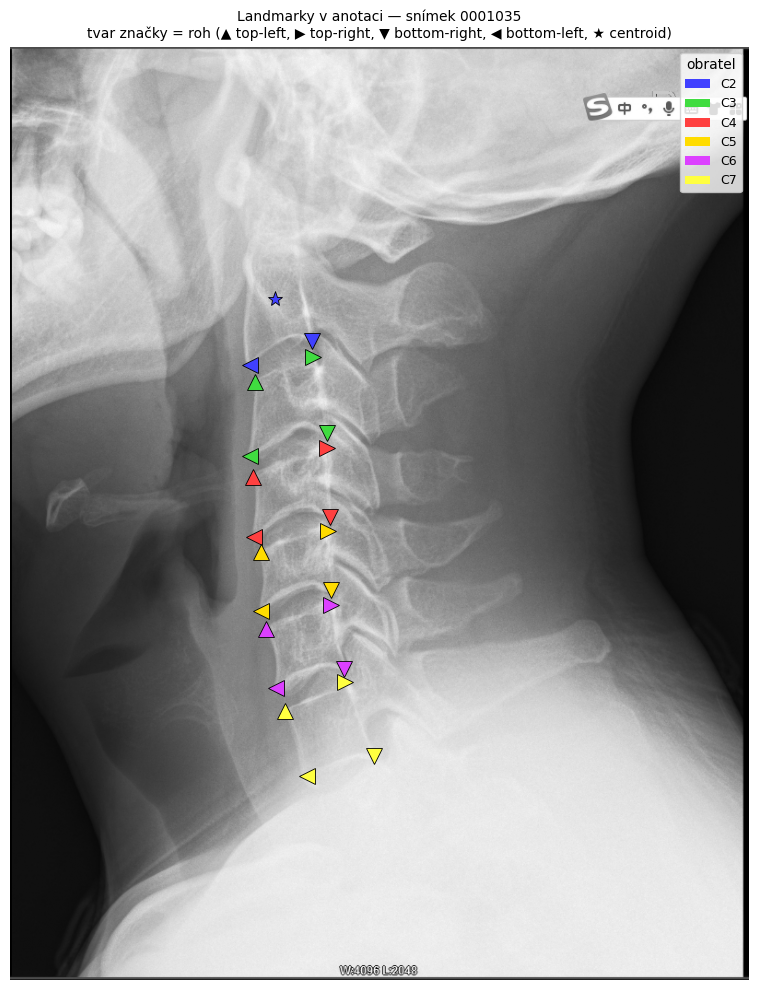

In [4]:
# Landmarky vykreslené na snímku.
# Body se barví podle obratle (legenda místo popisků u každého bodu — ty by se
# při 23 bodech překrývaly a byly by nečitelné). Tvar značky rozlišuje roh.
img = cv2.imread(str(IMAGES_DIR / f"{example}.png"), cv2.IMREAD_GRAYSCALE)
code_to_class = {f"C{i}": i - 1 for i in range(2, 8)}     # C2->1 ... C7->6
corner_marker = {"top left": "^", "top right": ">", "bottom right": "v",
                 "bottom left": "<", "centroid": "*"}

plt.figure(figsize=(8, 10))
plt.imshow(img, cmap="gray")
for s in ann["shapes"]:
    code, _, corner = s["label"].strip().partition(" ")
    x, y = s["points"][0]
    color = CLASS_PALETTE_RGB[code_to_class[code]] / 255
    plt.plot(x, y, corner_marker.get(corner, "o"), ms=11, color=color,
             markeredgecolor="black", markeredgewidth=0.6)

plt.legend(handles=legend_patches(), loc="upper right", fontsize=9, title="obratel")
plt.title(f"Landmarky v anotaci — snímek {example}\n"
          f"tvar značky = roh (▲ top-left, ▶ top-right, ▼ bottom-right, ◀ bottom-left, ★ centroid)",
          fontsize=10)
plt.axis("off"); plt.tight_layout(); plt.show()

## 3. Rasterizace — z landmarků na masku

Síť potřebuje masku, kde má každý pixel přiřazenou třídu. Skript
`scripts/rasterize_masks.py` proto rohové body poskládá do polygonu
(čtyřúhelník pro C3–C7, trojúhelník pro C2) a vyplní ho hodnotou třídy:

| hodnota | 0 | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|---|
| třída | pozadí | C2 | C3 | C4 | C5 | C6 | C7 |

**Metodický důsledek, který patří do zprávy:** maska je *čtyřúhelníková
aproximace* obratlového těla, ne jeho přesný obrys. Tím je omezená horní hranice
dosažitelného Dice — ale omezená **stejně pro všechny tři porovnávané modely**,
takže srovnání zůstává platné.

In [5]:
# Data už jsou vygenerovaná; přegenerování by trvalo pár minut.
# Odkomentuj, pokud je potřeba je vyrobit znovu:
# run_script("scripts/rasterize_masks.py")

n_masks = len(list(MASKS_DIR.glob("*.png")))
print(f"hotových masek: {n_masks}")

hotových masek: 4963


hodnoty v masce: [0 1 2 3 4 5 6]
rozměr masky: (1014, 802) | rozměr snímku: (1014, 802)


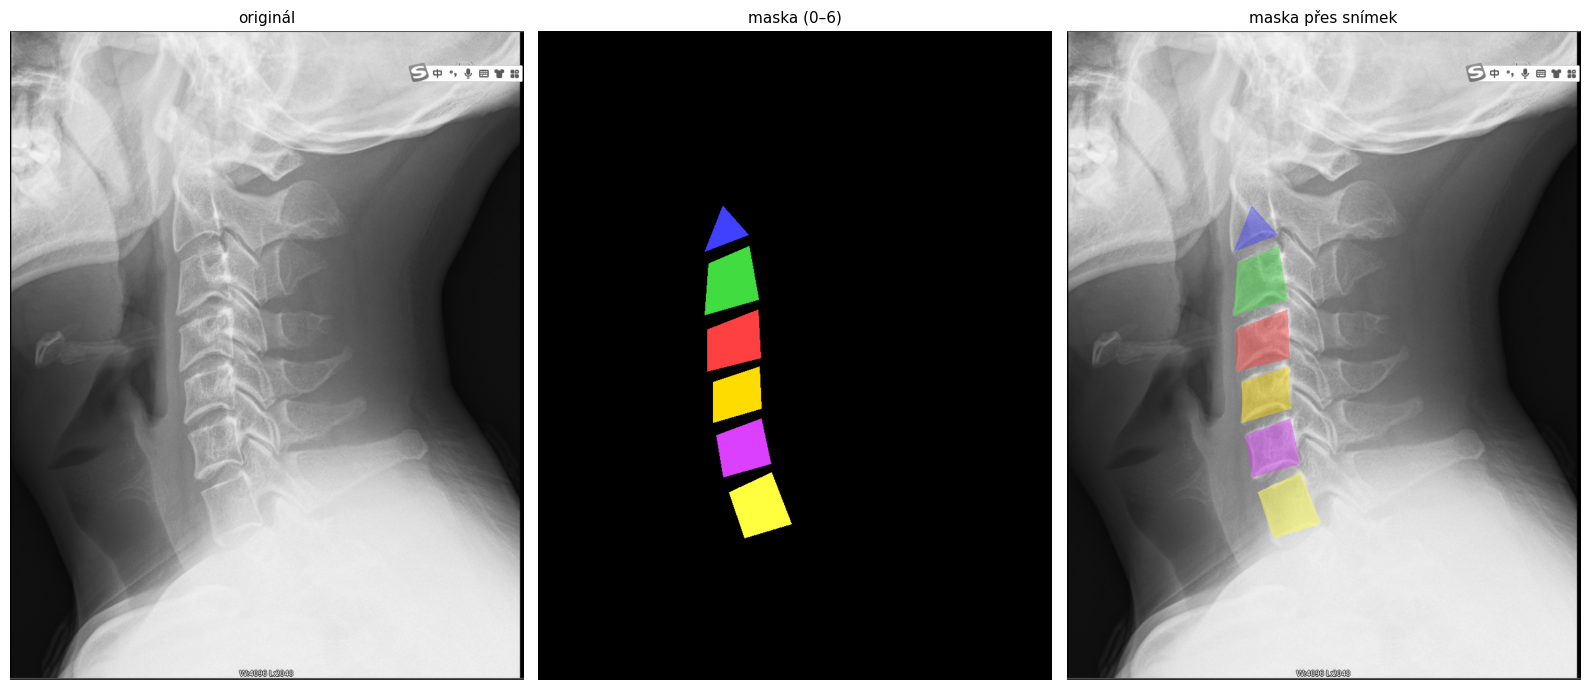

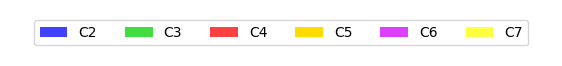

In [6]:
mask = cv2.imread(str(MASKS_DIR / f"{example}.png"), cv2.IMREAD_GRAYSCALE)
print("hodnoty v masce:", np.unique(mask))
print("rozměr masky:", mask.shape, "| rozměr snímku:", img.shape)

show_row([img, colorize(mask), overlay(img, mask)],
         ["originál", "maska (0–6)", "maska přes snímek"], cmap="gray")
plt.figure(figsize=(7, 0.6)); plt.legend(handles=legend_patches(), ncol=6, loc="center")
plt.axis("off"); plt.show()

### Proč existují dvě verze masek

Maska pro trénink má hodnoty 0–6. To je z 256 úrovní šedi tak málo, že v běžném
prohlížeči vypadá jako černý obrázek. Skript proto vedle ní ukládá i barevnou
verzi do `datasets-MASK-color/` — slouží **jen ke kontrole okem**, do tréninku
nevstupuje.

## 4. Rozdělení dat — prevence data leakage

Skript `scripts/build_fold_split.py` dělá dvě věci:

1. **K-Fold** (5 foldů) — původně plánovaná rigoróznější metodika
2. **Pevný split 60/20/20** — to, co se skutečně používá

Proč se od K-Foldu ustoupilo: znamenal by 5× trénink obou architektur od nuly,
což na dostupném hardwaru vychází na týdny (viz `devnotes/dodatek k trénování.md`).
Kód pro K-Fold ale v projektu **zůstal a spouští se** — je doklad, že
rigoróznější varianta byla navržena, odbenchmarkována a vědomě zamítnuta.

Rozdělení na tři části je přísnější než pouhé train/val:

| množina | role |
|---|---|
| **train** | učí se na ní model (gradient) |
| **val** | hlídá přetrénování, vybírá se podle ní nejlepší checkpoint |
| **test** | **nedotčená** — otevře se až na konec pro srovnání všech tří modelů |

Kdyby se checkpoint vybíral podle téže sady, na které se pak měří výsledek,
bylo by finální číslo nadhodnocené.

In [7]:
info = json.loads((FOLDS_DIR / "fixed_split_info.json").read_text(encoding="utf-8"))
print(json.dumps(info, ensure_ascii=False, indent=2))

{
  "dataset_name": "atlas_vertebra",
  "seed": 42,
  "train_frac": 0.6,
  "val_frac": 0.2,
  "test_frac": 0.2,
  "n_total": 4963,
  "counts": {
    "train": 2978,
    "val": 993,
    "test": 992
  },
  "role": {
    "train": "gradientový trénink",
    "val": "hlídání přetrénování + výběr best checkpointu během tréninku",
    "test": "nedotčený, sdílený test set pro finální srovnání U-Net / UNETR / TotalSegmentator2D"
  }
}


In [8]:
# Kontrola, že se množiny nepřekrývají (to je celá pointa)
sets = {name: set(pd.read_csv(FOLDS_DIR / f"{name}.csv")["image"]) for name in ["train", "val", "test"]}
for a in sets:
    for b in sets:
        if a < b:
            print(f"průnik {a} ∩ {b}: {len(sets[a] & sets[b])}")
print("sjednocení:", len(set().union(*sets.values())), "z celkem", len(stems))

průnik train ∩ val: 0
průnik test ∩ train: 0
průnik test ∩ val: 0
sjednocení: 4963 z celkem 4963


## 5. Předpočítaná ekvalizace histogramu (CLAHE)

CLAHE zvýrazní kontrast kostních struktur. Původně se počítala za běhu tréninku,
což se ukázalo jako **úzké hrdlo celé pipeline**: měření ukázalo ~13,7 ms práce
na CPU na jeden vzorek proti 21 ms výpočtu na GPU pro celou dávku osmi vzorků —
grafika tedy z 80 % času jen čekala.

Navíc se kvůli `patches_per_image: 8` tentýž snímek zpracovával **osmkrát za
epochu** se stejným výsledkem.

Skript `scripts/precompute_heqv.py` proto CLAHE spočítá jednou dopředu.
Sémantika zůstává stejná — CLAHE je adaptivní a musí se počítat na celém snímku
před vyříznutím výřezu, což předpočítání zachovává.

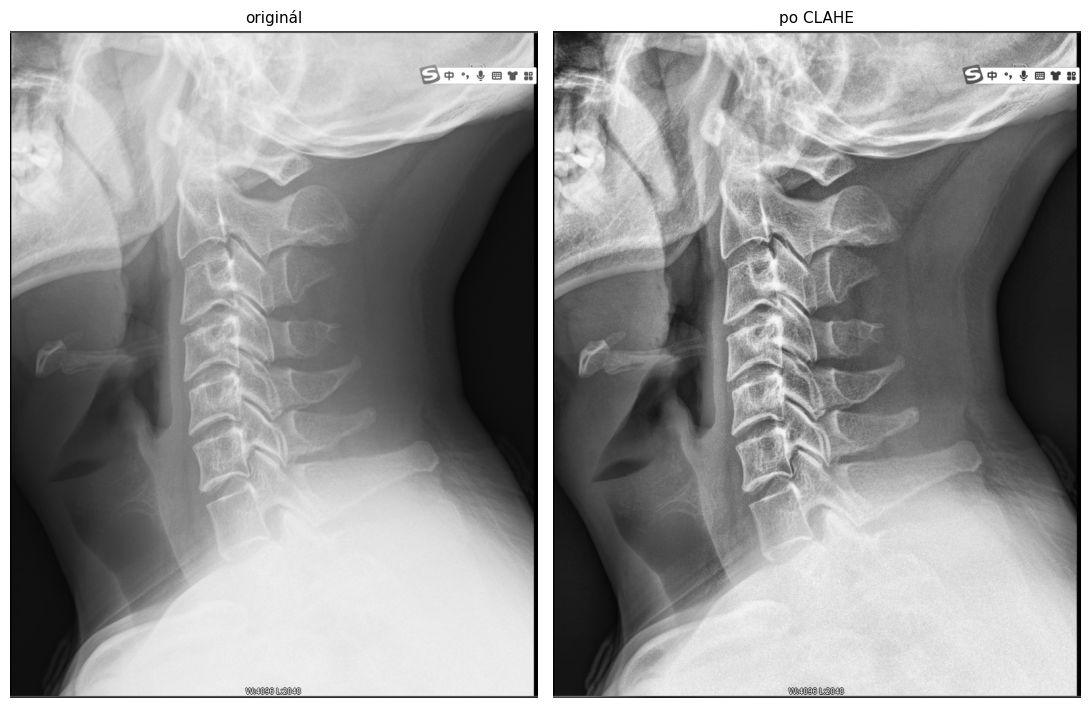

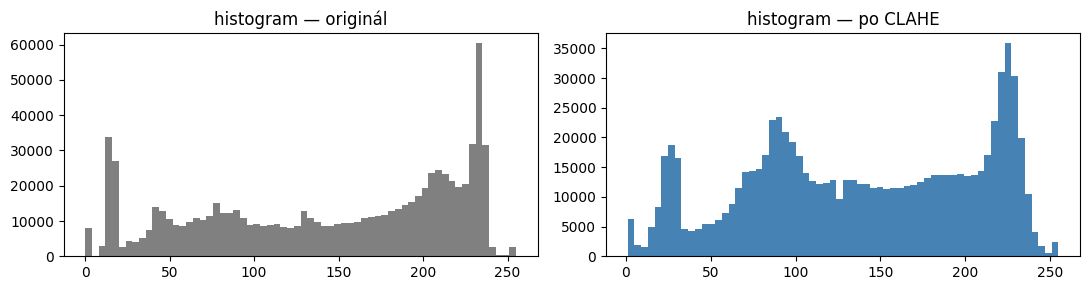

In [9]:
heqv = cv2.imread(str(IMAGES_HEQV_DIR / f"{example}.png"), cv2.IMREAD_GRAYSCALE)
show_row([img, heqv], ["originál", "po CLAHE"], figsize=(11, 7), cmap="gray")

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].hist(img.ravel(), bins=64, color="gray"); ax[0].set_title("histogram — originál")
ax[1].hist(heqv.ravel(), bins=64, color="steelblue"); ax[1].set_title("histogram — po CLAHE")
plt.tight_layout(); plt.show()

## 6. Statistika datasetu

Kolik plochy vlastně obratle zabírají? Odpověď vysvětluje, proč se metriky
počítají **bez pozadí** — a proč se používá Dice loss.

podíl obratlů na ploše: průměr 3.13 %, rozsah 1.96–4.67 %
rozlišení snímků: výška 700–765, šířka 494–675


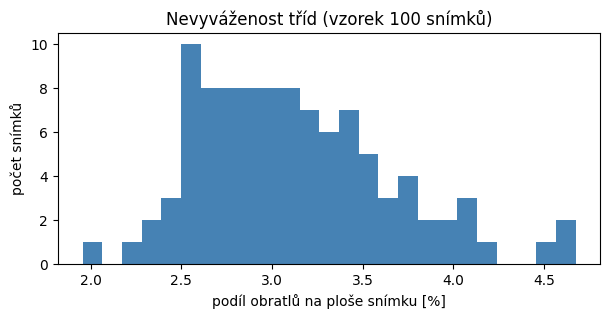

In [10]:
rng = np.random.default_rng(42)
sample = rng.choice(stems, size=100, replace=False)

shares, sizes = [], []
for st in sample:
    m = cv2.imread(str(MASKS_DIR / f"{st}.png"), cv2.IMREAD_GRAYSCALE)
    shares.append((m > 0).sum() / m.size * 100)
    sizes.append(m.shape)

print(f"podíl obratlů na ploše: průměr {np.mean(shares):.2f} %, "
      f"rozsah {np.min(shares):.2f}–{np.max(shares):.2f} %")
print(f"rozlišení snímků: výška {min(s[0] for s in sizes)}–{max(s[0] for s in sizes)}, "
      f"šířka {min(s[1] for s in sizes)}–{max(s[1] for s in sizes)}")

plt.figure(figsize=(7, 3))
plt.hist(shares, bins=25, color="steelblue")
plt.xlabel("podíl obratlů na ploše snímku [%]"); plt.ylabel("počet snímků")
plt.title("Nevyváženost tříd (vzorek 100 snímků)"); plt.show()

**Závěr:** obratle zabírají kolem 3 % plochy. Model, který by predikoval
výhradně pozadí, by měl přes 96 % pixelů správně — proto se jako hlavní metrika
používá **Dice průměrovaný přes třídy C2–C7 bez pozadí** a jako ztrátová funkce
kombinace Dice + Cross-Entropy.

Rozlišení snímků se navíc liší, což je důvod, proč se trénuje na výřezech pevné
velikosti a při vyhodnocení se používá sliding-window inference.

➡️ Dál: [`02_trenink_unet.ipynb`](02_trenink_unet.ipynb)